# Chapter 40. Feature engineering

So far, we have relied on the assumption that data is provided in a tidy numerical format, formatted into a `[n_samples, n_features]` matrix.
In reality, data rarely appears like this. 

_Feature engineering_ is a set of procedures through which we can turn any data into numbers that we can use to build a feature matrix.

Examples of data that inherently comes as numerical features:
- Measuring the size and weight of a specimen
- Measuring the height of human individuals
- The price of housing and median household income in a given area

In this lecture, we will discuss data that is not inherently numeric, and we will discuss methods to turn them into meaningful numerical representations. Examples of these data types are:
- Categorical features
- Text features


# Categorical Features

Suppose we have data for housing prices in different areas. Some fields may be numerical, such as "price" and "rooms", others may be categorial, like "neighborhood". For instance:

In [18]:
data = [
            {'price': 850000, 'rooms': 4, 'neighborhood': 'Queen Anne'},
            {'price': 700000, 'rooms': 3, 'neighborhood': 'Fremont'},
            {'price': 650000, 'rooms': 3, 'neighborhood': 'Wallingford'},
            {'price': 600000, 'rooms': 2, 'neighborhood': 'Fremont'}
        ]

A straightfoward (and inadequate for Scikit-Learn) numerical mapping could be converting neighborhoods into different integers:

In [19]:
{'Queen Anne': 1, 'Fremont': 2, 'Wallingford': 3};

This is __not useful__ in Scikit-Learn. The package will make assumption about numerical values and this would imply relations such as _Queen Anne < Fremont_.

### One-hot encoding

One useful solution to encode categorical data into numerical form is to use _one-hot encoding_.

This method uses a vector space to represent each category in orthogonal components. In practice, this is implemented by creating columns for each unique category, columns will hold values 0 or 1 indicating the presence or absence of that category.

Scikit-Learn provides the `DictVectorizer` to do this:

In [20]:
from sklearn.feature_extraction import DictVectorizer
vec = DictVectorizer(sparse=False, dtype=int)
vec.fit_transform(data)


array([[     0,      1,      0, 850000,      4],
       [     1,      0,      0, 700000,      3],
       [     0,      0,      1, 650000,      3],
       [     1,      0,      0, 600000,      2]])

The `neighborhood` column has been expanded into three separate columns representing the three neighborhood categories.

To see the meaning of each column:

In [21]:
vec.get_feature_names_out()

array(['neighborhood=Fremont', 'neighborhood=Queen Anne',
       'neighborhood=Wallingford', 'price', 'rooms'], dtype=object)

One clear downside of this approach is that the one-hod encoded matrices tend to be sparse.

Scikit-Learn provides an efficient way to encode sparse matrices:

In [22]:
vec = DictVectorizer(sparse=True, dtype=int)
vec.fit_transform(data)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12 stored elements and shape (4, 5)>

Scikit-Learn sparse matrices can be used with nearly every model in fitting and evaluation.

# Text features

To analyze text data, we must convert it to some numeric format.
One of the simples methods of encoding text is by _word counts_: take each snippet of text and count the occurrences of each word in it, putting the results in a table. 

For instance, consider the following sentences:

In [ ]:
sample = ['problem of evil',
          'evil queen',
          'horizon problem']

We can perform a vectorization of this data by creating columns for each word, like "problems", "of", "evil", "queen", etc.

Scikit-Learn provides a `CountVectorizer` facility to perform this operation:

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
X = vec.fit_transform(sample)
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (3, 5)>

The result is a sparse matrix. We can convert it to a Pandas `DataFrame`:

In [24]:
import pandas as pd
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,evil,horizon,of,problem,queen
0,1,0,1,1,0
1,1,0,0,0,1
2,0,1,0,1,0



<details>
<summary>
What are some downsides of this method?

</summary>
If some word appears very frequently, it will receive too much weight. Which words appear very often?
</details>


### Term frequency-inverse document frequency (TF-IDF)

This is a more sophisticated procedure for vectorizing text that relies on the relevance of words found in the data.

_Term frequency_(TF) relates to the overall frequency (normalized count) of a word.

_Inverse document frequency_(IDF) determines the relevance of a word based on how many documents it appears. Words that appear in many documents are less relevant (think stopwords like 'the', 'with', or verbs like 'said', 'take', etc.).

### Vocabulary


Both `CountVectorizer` and `TfidfVectorizer` create columns for each word seen in the training data. If a corpus (collection of documents) contains 200,000 unique words, the feature matrix will have shape `[n, 200000]`.

### Hashing vectorizer

Another method for encoding text is the `HasingVectorizer`. This method applied a hashing function to words in the text and includes them in a hash table (feature matrix). Each word is mapped to a column, columns hold normalized word counts (frequencies).

In [25]:
from sklearn.feature_extraction.text import HashingVectorizer

vec = HashingVectorizer(n_features=2**4)
X = vec.fit_transform(sample)
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (3, 16)>
  Coords	Values
  (0, 12)	0.5773502691896258
  (0, 13)	0.5773502691896258
  (0, 15)	-0.5773502691896258
  (1, 13)	0.7071067811865475
  (1, 14)	-0.7071067811865475
  (2, 5)	-0.7071067811865475
  (2, 15)	-0.7071067811865475


# Derived Features

Some features can be derived from existing ones using a mathematical principle or procedure.
We have previously used the `PolynomialFeatures` module which converts a linear feature to polynomial ones. Effectively, we performed polynomial regression by using a linear regressor on polynomial features.

# Imputation of Missing Data

A recurring issue in feature engineering is handling of missing data.

In [28]:
import numpy as np
from numpy import nan
X = np.array([[ nan, 0,   3  ],
            [ 3,   7,   9  ],
            [ 3,   5,   2  ],
            [ 4,   nan, 6  ],
            [ 8,   8,   1  ]])

We need to determine the appropriate fill value to replace missing data.
This is known as _imputation_. Some strategies are as simple as replacing missing values with the mean of the column.

In [29]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='mean')
y = np.array([14, 16, -1,  8, -5])
X2 = imp.fit_transform(X)
X2

array([[4.5, 0. , 3. ],
       [3. , 7. , 9. ],
       [3. , 5. , 2. ],
       [4. , 5. , 6. ],
       [8. , 8. , 1. ]])

The resulting matrix can be used to fit a `LinearRegression` model.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
model = LinearRegression().fit(X2, y)
model.predict(X2)

array([13.14869292, 14.3784627 , -1.15539732, 10.96606197, -5.33782027])

# Feature Pipelines

A pipline can be used to streamline all the data processing steps covered so far.

If you wish to string together multiple steps, you might want to do something like this:

1. Impute missing values using mean.
2. Transform features.
3. Fit a linear regression model.


To create a `Pipeline` with the previous steps:

In [32]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(SimpleImputer(strategy='mean'),
                    PolynomialFeatures(degree=2),
                    LinearRegression())

The created pipeline behaves like a standard Scikit-Learn object and can be used like one:

In [33]:
model.fit(X,y)
print(y)
print(model.predict(X))

[14 16 -1  8 -5]
[14. 16. -1.  8. -5.]


# What is the meaning?

One limitation shared by all count-based text vectorizers is that they fail to capture the meaning of words. For instance, consider the phrases:

1. "the car is blue"
2. "the cat is smart"
3. "the vehicle was parked"

Each sentence uses completely different words (if not for the common stopwords like 'the' and 'is').

One may argue that sentences 1 and 3 from above are more similar to each other than they are to sentence 2. This requires information about the _semantics_ of the text, which is not captured by count-based methods.

# Word embeddings

Word embeddings is a technique to extract numerical features from text based on word meanings.

Most methods are based on the __distributional semantics hypothesis__: words of similar meaning appear in similar contexts.

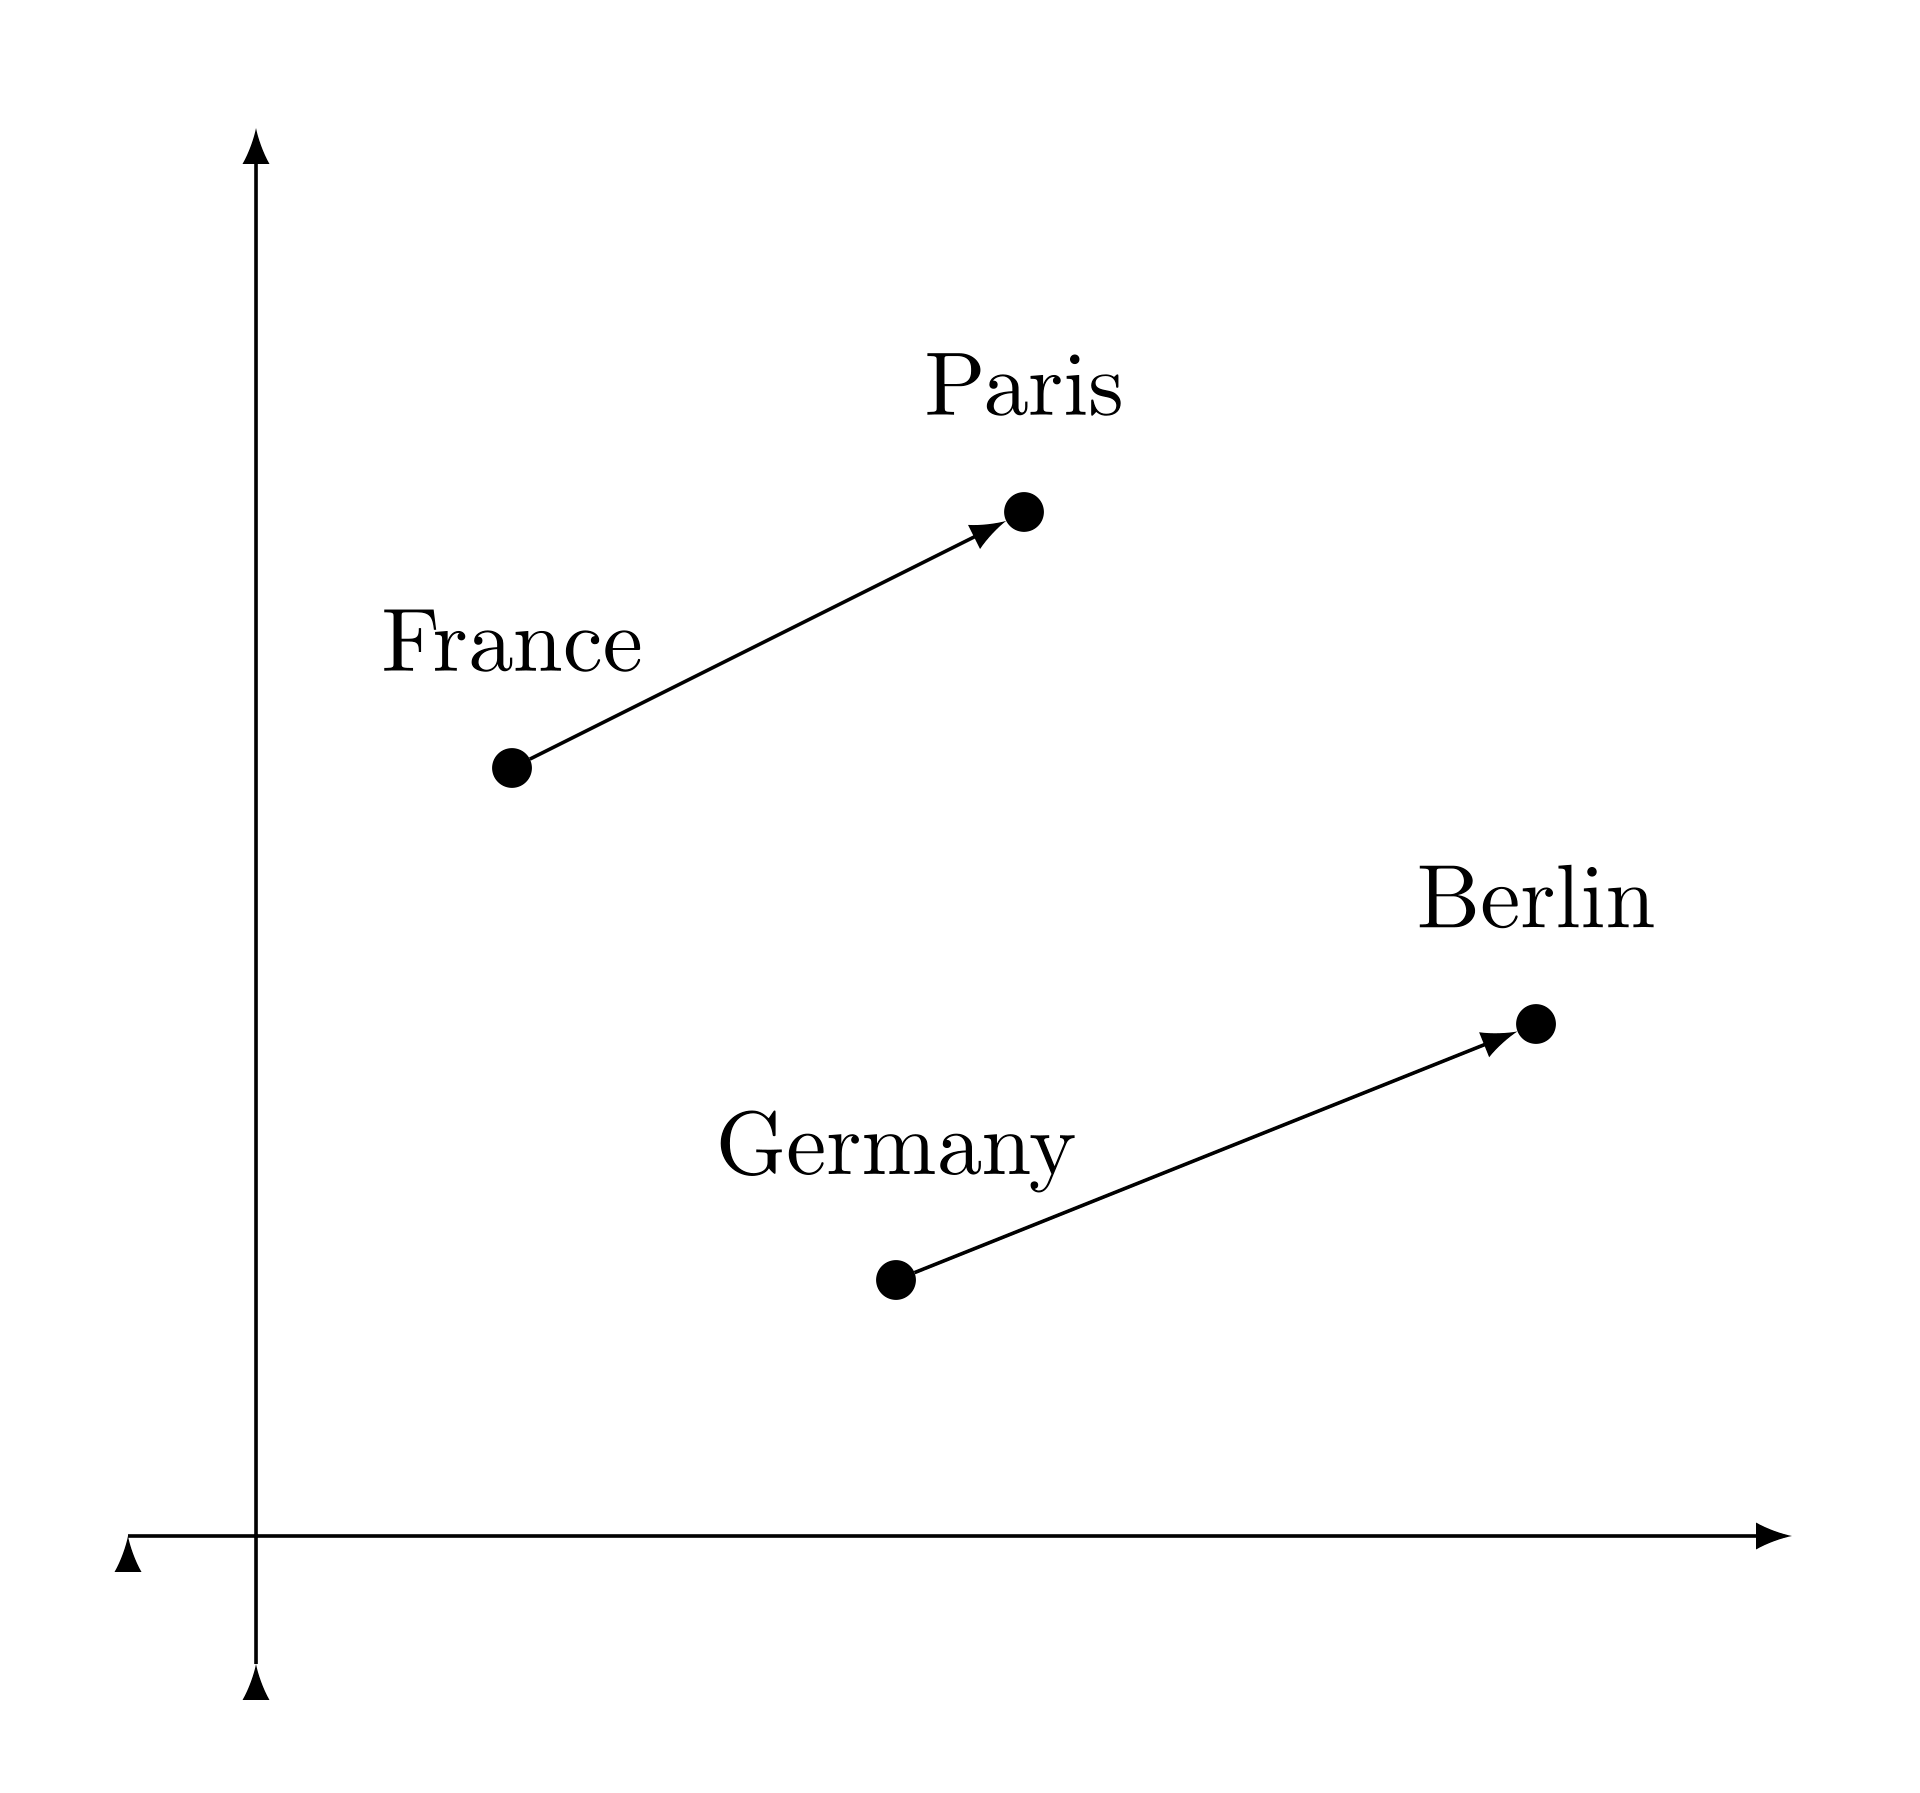

Embeddings can be applied to different granularities of text. 

- __Word embeddings__: each word produces one fixed-length vector.
- __Document/sentence embeddings__: Entire documents or sentences are converted into a fixed-length vector.

Embeddings are obtained from a machine learning procedure on their own. Often relying on unsupervised or self-supervised approaches. We may utilize these _pre-trained_ embeddings to obtain a feature matrix for text data.

### Advantages of word embeddings

- They capture semantic relation between words and sentences.
- Their dense representations are compact and efficient when compared to sparse count matrices.
- They produce fixed-length vectors that do not depend on the size of the vocabulary.

The library we will use for word embeddings is `sklearn-embeddings`:

In [ ]:
%pip install sklearn_embeddings

## Tokenization

Text data comes as strings of multiple words. However, text analysis typically requires us to identify each individual word in a text.

Consider the following sentence:

`"The quick brown fox jumped over the lazy dog."`

A naive way to retrieve the words in the text is by splitting the string on blank spaces.

This procedure is known as __tokenization__. Each piece of the input text becomes a _token_.

E.g.:

In [34]:
sentence = "The quick brown fox jumped over the lazy dog."
tokens = sentence.split(" ")

tokens

['The', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'lazy', 'dog.']

There are many issues with this approach. First, we do not handle punctuation marks, capitalization, and multiple forms of the same word, like plurals and verb tense.
Tokenization is part of a text preprocessing pipeline.

Let us use `sklearn-embeddings` to compare the similarity between the three sentences from above.

Word and sentence embeddings are often compared using _cosine similarity_ or _cosine distance_. The module `SentenceTransformerEmbedding` tokenizes and applies feature extraction to an input text using a pre-trained model.

In [35]:
from sklearn_embeddings import SentenceTransformerEmbedding

sentences = ["the car is blue", "the cat is smart", "the vehicle was parked"]
model = SentenceTransformerEmbedding()
x_sentences = model.fit_transform(sentences)
print(x_sentences.shape)


(3, 384)


Notice how the above code has converted the three sentences into a `(3, 384)` feature matrix. It is also a _dense_ and compact representation than the sparse word count matrices even when the vocabulary is large.

We will now compare the similarity between each sentence.

In [36]:
from scipy.spatial.distance import cosine

def cosine_similarity(x, y):
    # The cosine similarity can be obtained by: cos_sim = 1 - cos_dist
    return 1 - cosine(x, y)

print(sentences)

print(f"Similarity 1 and 2: {cosine_similarity(x_sentences[0], x_sentences[1])}")
print(f"Similarity 1 and 3: {cosine_similarity(x_sentences[0], x_sentences[2])}")

['the car is blue', 'the cat is smart', 'the vehicle was parked']
Similarity 1 and 2: 0.17342114448547363
Similarity 1 and 3: 0.45529884099960327


The feature matrix and models from `sklearn_embeddings` can be used along with `Scikit-Learn` interface and pipelines.


The following uses a feature matrix from SentenceTransformerEmbeddings to train a classifier that predicts whether a comment is positive or not.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Sample data
documents = ["The food was great.", "Not expensive and good service", "Not worth the money", "I've had better"]

# Labels
is_positive = [True, True, False, False]

# Create a pipeline with the embedding model and a classifier
pipeline = make_pipeline(
    SentenceTransformerEmbedding(), 
    LogisticRegression()
    )

# Fit the model
pipeline.fit(documents, is_positive)

# Make predictions
predictions = pipeline.predict(["So delicious!", "Not for me"])

print(predictions)


[ True False]


In [46]:
s = "TOO EXPENSIVE!!!"

print(pipeline.predict([s]))

[False]


In [ ]:
%pip install torch -U